# TON_IoT Random Forest 

Single notebook with separate cells for each core machine learning step using a Random Forest classifier.

## 1) Import Libraries and Set Reproducibility

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
print('Imports loaded. RANDOM_STATE =', RANDOM_STATE)

Imports loaded. RANDOM_STATE = 42


## 2) Load Dataset

In [4]:
DATA_PATH = Path('../data/ton_iot/train_test_network.csv')

df = pd.read_csv(DATA_PATH)
print('Loaded:', DATA_PATH)
print('Shape:', df.shape)
df.head()

Loaded: ..\data\ton_iot\train_test_network.csv
Shape: (211043, 44)


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


## 3) Inspect Data and Define Features/Target

In [5]:
print('Data types:')
print(df.dtypes.head(20))

print('\nMissing values (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))

if 'type' in df.columns:
    target_col = 'type'
elif 'label' in df.columns:
    target_col = 'label'
else:
    raise ValueError('No target column found. Expected one of: type, label')

print('\nChosen target column:', target_col)
print('\nTarget distribution:')
print(df[target_col].value_counts(dropna=False).head(20))

leakage_or_id_cols = ['ts', 'pkSeqID', 'seq', 'attack']
remove_cols = [c for c in leakage_or_id_cols if c in df.columns and c != target_col]

X = df.drop(columns=[target_col] + remove_cols)
y = df[target_col].astype(str)

print('\nRemoved columns:', remove_cols)
print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Data types:
src_ip              str
src_port          int64
dst_ip              str
dst_port          int64
proto               str
service             str
duration        float64
src_bytes         int64
dst_bytes         int64
conn_state          str
missed_bytes      int64
src_pkts          int64
src_ip_bytes      int64
dst_pkts          int64
dst_ip_bytes      int64
dns_query           str
dns_qclass        int64
dns_qtype         int64
dns_rcode         int64
dns_AA              str
dtype: object

Missing values (top 10):
src_ip        0
src_port      0
dst_ip        0
dst_port      0
proto         0
service       0
duration      0
src_bytes     0
dst_bytes     0
conn_state    0
dtype: int64

Chosen target column: type

Target distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
ransomware    20000
scanning      20000
xss           20000
mitm           1043
Name: count, dtype: int64

Removed colum

## 4) Handle Missing Values and Encode Categories

In [6]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

Numeric features: 17
Categorical features: 26


## 5) Split Data into Train/Test Sets

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train classes:', y_train.nunique())

X_train: (168834, 43) | X_test: (42209, 43)
y_train classes: 10


## 6) Build Preprocessing + Random Forest Pipeline

In [8]:
baseline_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 7) Train the Model

In [9]:
baseline_pipeline.fit(X_train, y_train)
print('Baseline RandomForest model trained.')

Baseline RandomForest model trained.


## 8) Evaluate with Classification Metrics

Accuracy: 0.9952
Precision (weighted): 0.9952
Recall (weighted): 0.9952
F1-score (weighted): 0.9952

Classification Report:

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.99      0.99      0.99      4000
         dos       0.99      0.99      0.99      4000
   injection       0.99      0.99      0.99      4000
        mitm       0.90      0.96      0.93       209
      normal       1.00      1.00      1.00     10000
    password       1.00      0.99      1.00      4000
  ransomware       1.00      1.00      1.00      4000
    scanning       0.99      0.99      0.99      4000
         xss       1.00      1.00      1.00      4000

    accuracy                           1.00     42209
   macro avg       0.99      0.99      0.99     42209
weighted avg       1.00      1.00      1.00     42209



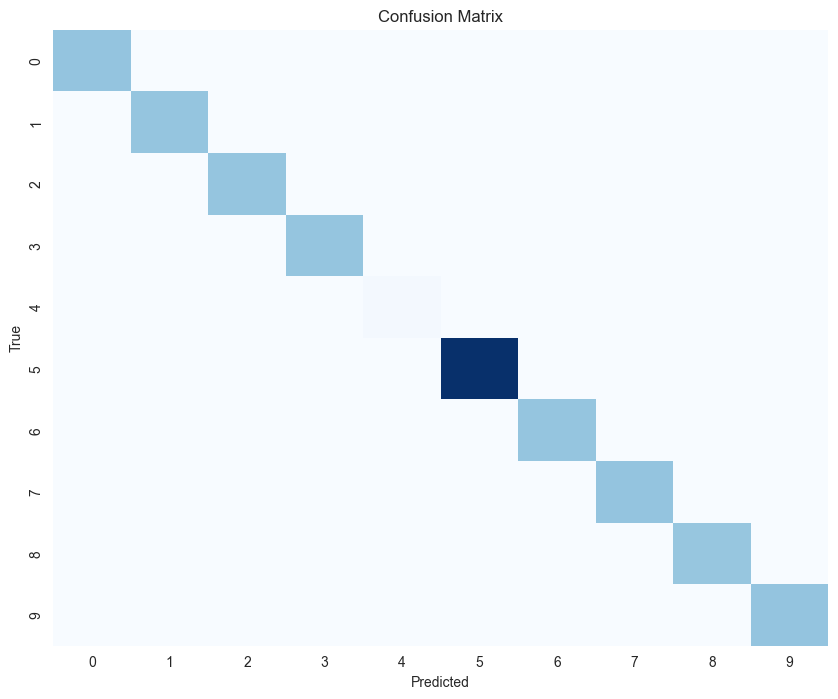

ROC-AUC: 1.0000


In [10]:
y_pred = baseline_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
    y_test, y_pred, average='weighted', zero_division=0
)

print(f'Accuracy: {acc:.4f}')
print(f'Precision (weighted): {precision_w:.4f}')
print(f'Recall (weighted): {recall_w:.4f}')
print(f'F1-score (weighted): {f1_w:.4f}')
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, zero_division=0))

labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

roc_auc_value = None
if hasattr(baseline_pipeline, 'predict_proba'):
    y_proba = baseline_pipeline.predict_proba(X_test)
    if len(labels_sorted) == 2:
        positive_class = labels_sorted[1]
        class_index = list(baseline_pipeline.classes_).index(positive_class)
        roc_auc_value = roc_auc_score((y_test == positive_class).astype(int), y_proba[:, class_index])
    else:
        y_test_bin = label_binarize(y_test, classes=baseline_pipeline.classes_)
        roc_auc_value = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')

if roc_auc_value is not None:
    print(f'ROC-AUC: {roc_auc_value:.4f}')
else:
    print('ROC-AUC not computed (predict_proba unavailable).')

baseline_metrics = {
    'accuracy': float(acc),
    'precision_weighted': float(precision_w),
    'recall_weighted': float(recall_w),
    'f1_weighted': float(f1_w),
    'roc_auc': float(roc_auc_value) if roc_auc_value is not None else None,
}

## 9) Plot Feature Importance

,feature,importance
7,num__src_ip_bytes,0.079791
0,num__src_port,0.061883
2,num__duration,0.056172
1,num__dst_port,0.053579
9,num__dst_ip_bytes,0.050461
3,num__src_bytes,0.042775
39,cat__src_ip_192.168.1.32,0.035140
6,num__src_pkts,0.035069
37,cat__src_ip_192.168.1.30,0.033130
8,num__dst_pkts,0.032628


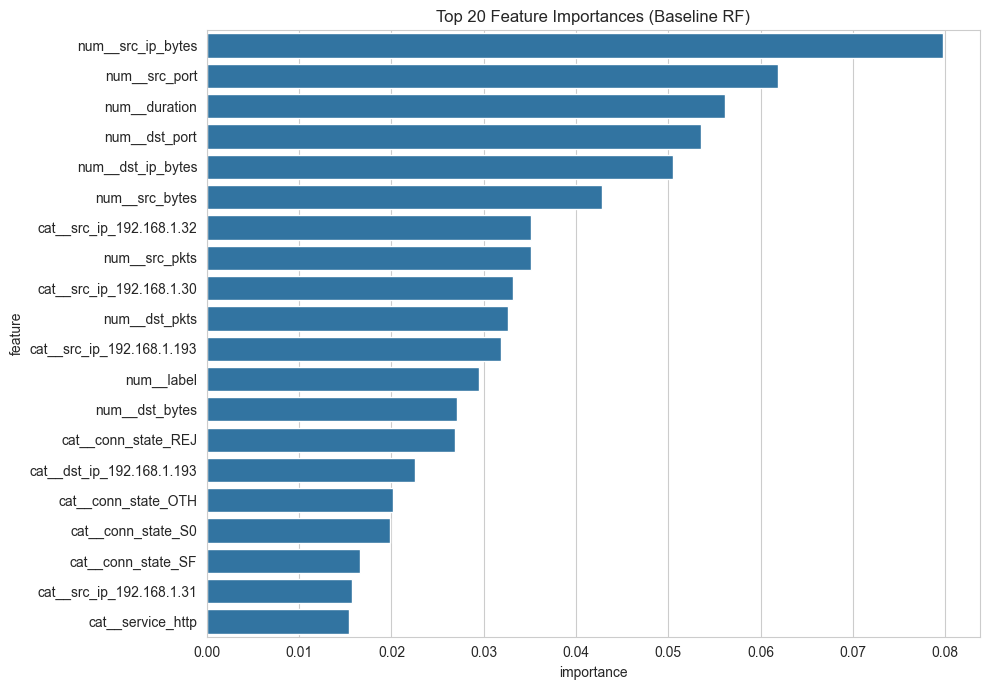

In [9]:
rf_estimator = baseline_pipeline.named_steps['model']
prep = baseline_pipeline.named_steps['preprocess']

feature_names = prep.get_feature_names_out()
importances = rf_estimator.feature_importances_

fi = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(20)
)

display(fi)

plt.figure(figsize=(10, 7))
sns.barplot(data=fi, x='importance', y='feature', orient='h')
plt.title('Top 20 Feature Importances (Baseline RF)')
plt.tight_layout()
plt.show()

## 10) Save Trained Model

In [14]:
MODEL_DIR = Path('../models/ton_iot')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / 'TON_IOT_INTRUSION_DETECTION_MODEL.joblib'
metadata_path = MODEL_DIR / 'TON_IOT_INTRUSION_DETECTION_MODEL_METADATA.json'

joblib.dump(baseline_pipeline, model_path)

metadata = {
    'dataset_path': str(DATA_PATH),
    'target_column': target_col,
    'n_samples': int(len(df)),
    'n_features': int(X.shape[1]),
    'train_size': int(len(X_train)),
    'test_size': int(len(X_test)),
    'random_state': RANDOM_STATE,
    'model': 'RandomForestClassifier',
    'model_params': baseline_pipeline.named_steps['model'].get_params(),
    'metrics': baseline_metrics,
}

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved model to:', model_path)
print('Saved metadata to:', metadata_path)

Saved model to: ..\models\ton_iot\TON_IOT_INTRUSION_DETECTION_MODEL.joblib
Saved metadata to: ..\models\ton_iot\TON_IOT_INTRUSION_DETECTION_MODEL_METADATA.json


## 11) Generate Paper Charts (Architecture + Pipeline + Per-Class Metrics)

These cells generate the missing visualizations referenced in the research paper:
- System Architecture Diagram
- Data Preprocessing Pipeline Diagram
- Per-Class Performance Metrics (F1-score)

> Figures are also saved to `figures/ton_iot/` for direct use in LaTeX.

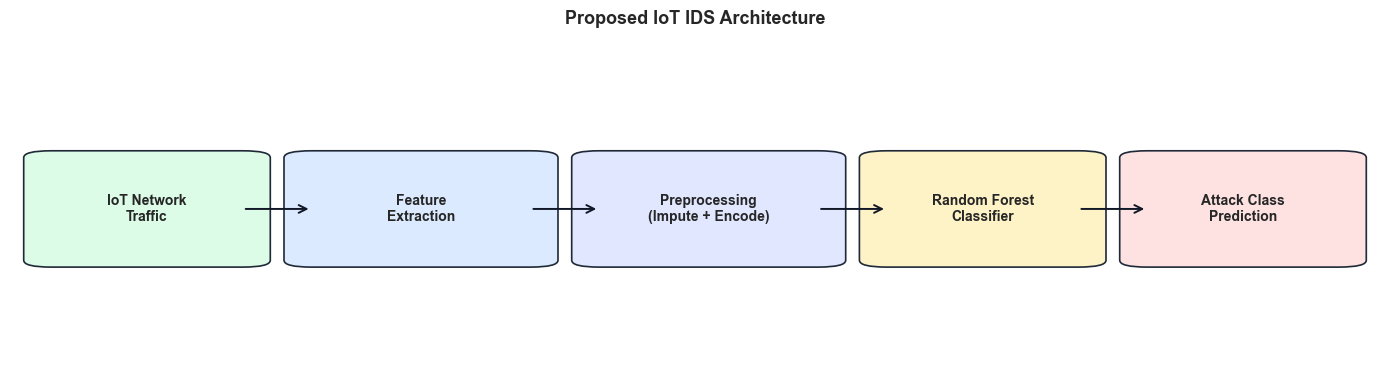

Saved: ..\figures\ton_iot\architecture_diagram.png


In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

FIG_DIR = Path('../figures/ton_iot')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 4))
ax = plt.gca()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

def add_box(x, y, w, h, text, color='#dbeafe'):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.02,rounding_size=0.02',
        linewidth=1.2,
        edgecolor='#1f2937',
        facecolor=color,
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10, weight='bold')

def add_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=14, linewidth=1.4, color='#111827')
    ax.add_patch(arrow)

# System architecture blocks
add_box(0.03, 0.35, 0.14, 0.30, 'IoT Network\nTraffic', '#dcfce7')
add_box(0.22, 0.35, 0.16, 0.30, 'Feature\nExtraction', '#dbeafe')
add_box(0.43, 0.35, 0.16, 0.30, 'Preprocessing\n(Impute + Encode)', '#e0e7ff')
add_box(0.64, 0.35, 0.14, 0.30, 'Random Forest\nClassifier', '#fef3c7')
add_box(0.83, 0.35, 0.14, 0.30, 'Attack Class\nPrediction', '#fee2e2')

# Arrows
add_arrow(0.17, 0.50, 0.22, 0.50)
add_arrow(0.38, 0.50, 0.43, 0.50)
add_arrow(0.59, 0.50, 0.64, 0.50)
add_arrow(0.78, 0.50, 0.83, 0.50)

plt.title('Proposed IoT IDS Architecture', fontsize=13, weight='bold', pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'architecture_diagram.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', FIG_DIR / 'architecture_diagram.png')

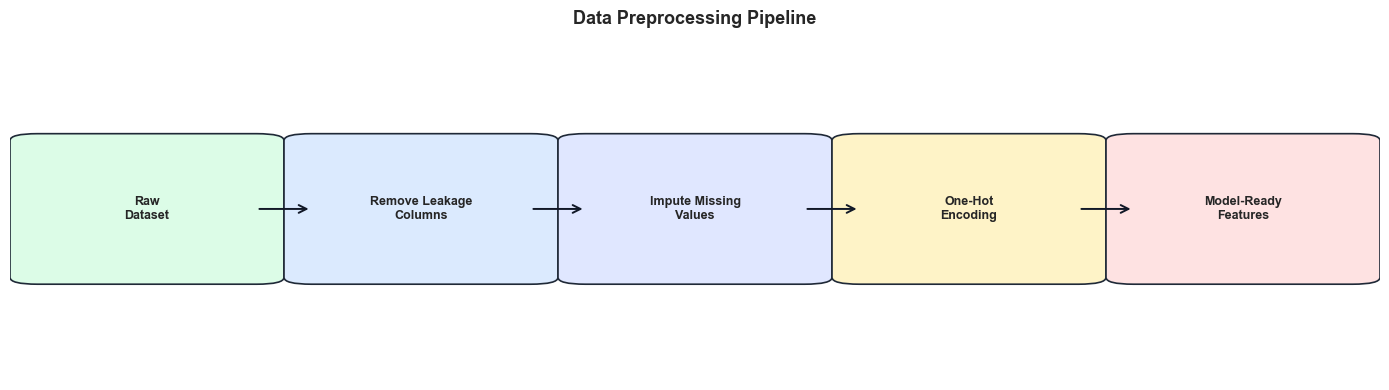

Saved: ..\figures\ton_iot\preprocessing_pipeline.png


In [3]:
plt.figure(figsize=(14, 4))
ax = plt.gca()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

def add_step(x, text, color):
    step = FancyBboxPatch(
        (x, 0.30), 0.16, 0.40,
        boxstyle='round,pad=0.02,rounding_size=0.02',
        linewidth=1.2,
        edgecolor='#1f2937',
        facecolor=color,
    )
    ax.add_patch(step)
    ax.text(x + 0.08, 0.50, text, ha='center', va='center', fontsize=9, weight='bold')

steps = [
    (0.02, 'Raw\nDataset', '#dcfce7'),
    (0.22, 'Remove Leakage\nColumns', '#dbeafe'),
    (0.42, 'Impute Missing\nValues', '#e0e7ff'),
    (0.62, 'One-Hot\nEncoding', '#fef3c7'),
    (0.82, 'Model-Ready\nFeatures', '#fee2e2'),
]

for x, label, color in steps:
    add_step(x, label, color)

for i in range(len(steps) - 1):
    x1 = steps[i][0] + 0.16
    x2 = steps[i + 1][0]
    arrow = FancyArrowPatch((x1, 0.50), (x2, 0.50), arrowstyle='->', mutation_scale=14, linewidth=1.4, color='#111827')
    ax.add_patch(arrow)

plt.title('Data Preprocessing Pipeline', fontsize=13, weight='bold', pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'preprocessing_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', FIG_DIR / 'preprocessing_pipeline.png')

,class,precision,recall,f1,support
0,backdoor,1.000000,1.000000,1.000000,4000
5,normal,1.000000,1.000000,1.000000,10000
7,ransomware,1.000000,1.000000,1.000000,4000
9,xss,0.999500,1.000000,0.999750,4000
6,password,0.996243,0.994500,0.995371,4000
1,ddos,0.993733,0.991000,0.992365,4000
2,dos,0.988517,0.990000,0.989258,4000
8,scanning,0.990706,0.986000,0.988347,4000
3,injection,0.986305,0.990250,0.988273,4000
4,mitm,0.900901,0.956938,0.928074,209


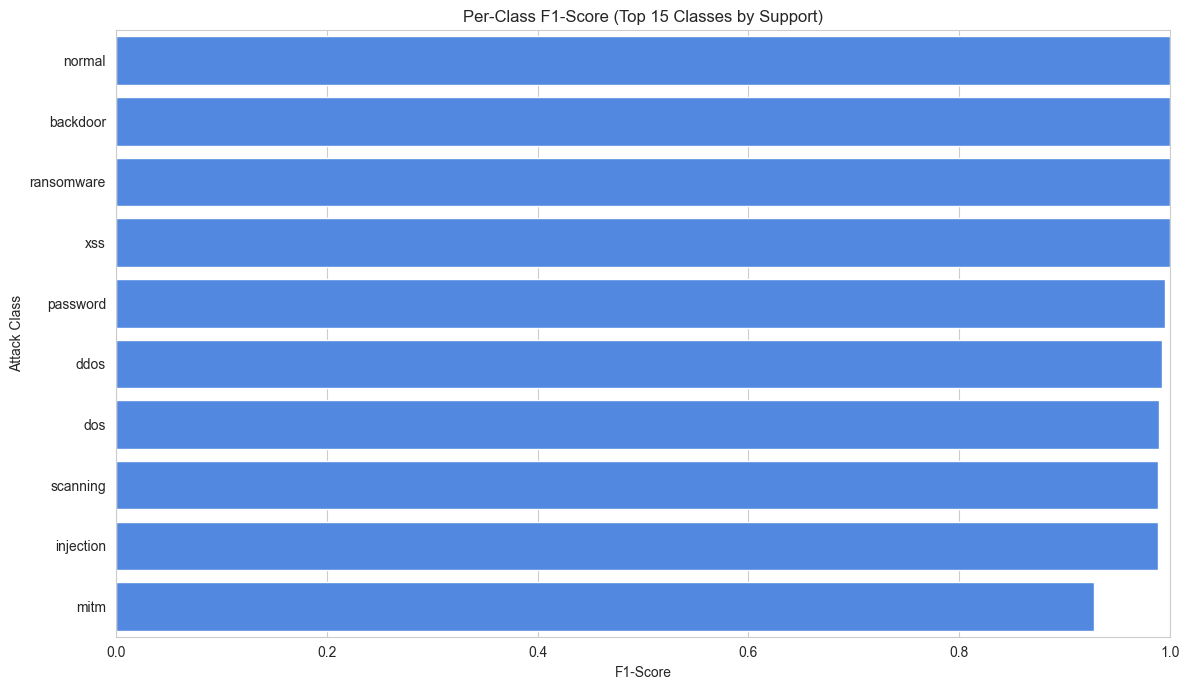

Saved: ..\figures\ton_iot\per_class_f1_scores.png


In [11]:
from sklearn.metrics import precision_recall_fscore_support

# Ensure required variables exist if this cell is run independently
if 'y_pred' not in globals():
    y_pred = baseline_pipeline.predict(X_test)
if 'y_test' not in globals():
    raise ValueError('y_test not found. Run the train/test split and evaluation cells first.')

labels_sorted = sorted(y.unique())
precision_c, recall_c, f1_c, support_c = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=labels_sorted,
    zero_division=0,
)

per_class_df = pd.DataFrame({
    'class': labels_sorted,
    'precision': precision_c,
    'recall': recall_c,
    'f1': f1_c,
    'support': support_c,
}).sort_values('f1', ascending=False)

display(per_class_df.head(15))

# Plot top-N classes by support for readability
top_n = 15
plot_df = per_class_df.sort_values('support', ascending=False).head(top_n).sort_values('f1', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df, x='f1', y='class', color='#3b82f6')
plt.xlim(0, 1.0)
plt.title(f'Per-Class F1-Score (Top {top_n} Classes by Support)')
plt.xlabel('F1-Score')
plt.ylabel('Attack Class')
plt.tight_layout()
plt.savefig(FIG_DIR / 'per_class_f1_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', FIG_DIR / 'per_class_f1_scores.png')